# M66 Pre-Final Scenario Implementation — High-Demand and Reduced-Service

**Scope owner:** Kawol — Scenario Implementation (High-Demand and Reduced-Service operating conditions)

**Branch:** `feature/prefinal-scenarios` (created from `main`)

This notebook builds on the completed Midterm work in `m66_baseline_simulation.ipynb` and implements the two Pre-Final stress-test scenarios listed as "Planned" in the project README:

- **High-Demand scenario** — passenger demand increased by 40%, published GTFS reference service unchanged.
- **Reduced-Service scenario** — passenger demand unchanged, exactly one scheduled trip removed from every study hour.

**Design rule followed throughout:** no separate simulation engine is built. The discrete-event engine (`handle_passenger_arrival`, `handle_bus_arrival`, `run_service_simulation`) is reused **unmodified** from the baseline notebook. Only the *inputs* passed into that engine change per scenario:

| Scenario | Passenger streams | Service schedule / occupancy / alighting |
|---|---|---|
| Baseline | Baseline demand | Baseline GTFS |
| High-Demand | +40% demand (new streams, same seeds) | Baseline GTFS (unchanged) |
| Reduced-Service | Baseline demand (same streams as Baseline) | GTFS with 1 trip removed per hour (recomputed occupancy/alighting) |

The Combined scenario (High-Demand + Reduced-Service together) and GA re-optimization under these conditions are **out of scope for this handoff** — see Section 15 (Scope Boundary).


In [1]:
# DATA SOURCES
# MTA Bus Stop Level Ridership: Beginning 2024
# https://data.ny.gov/d/fvdm-uavx
#
# MTA Developer Resources / Static GTFS
# https://www.mta.info/developers
#
# GTFS Schedule Reference
# https://gtfs.org/documentation/schedule/reference/
#
# DEVELOPMENT AND DOCUMENTATION NOTE
# This notebook reuses the data-loading, GTFS-parsing, occupancy/alighting,
# and discrete-event simulation code from m66_baseline_simulation.ipynb.
# Sections that are copied unmodified from the baseline notebook are marked
# "(reused, unmodified)" in their heading. Sections that generalize a baseline
# function so it accepts scenario inputs as parameters (instead of hardcoded
# notebook globals) are marked "(generalized from baseline)". New scenario
# logic (demand scaling, deterministic trip removal) is written for this
# handoff and is documented in-line with its own references.
#
# AI-assisted suggestions were used as a starting point for some Python code,
# following the same practice already documented in the baseline notebook.
# The code was adapted to the scenario requirements, run against the actual
# project data, and checked against the baseline results before handoff.


In [2]:
# Import the libraries used for data handling, simulation, and plotting.
from pathlib import Path
import heapq

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 1. Setup and Shared Configuration

In [3]:
# Define the main project directories and input file locations.
# Identical to the baseline notebook so this notebook can be run from the
# same `MODESIM_Project/code/` working directory.
project_dir = Path("..")

raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"
gtfs_dir = raw_dir / "gtfs_m"

figures_dir = project_dir / "output" / "figures"
tables_dir = project_dir / "output" / "tables"

clean_file = processed_dir / "MTA_M66_Selected_Stops_2025_CLEAN.csv"
raw_file = raw_dir / "MTA_M66_Eastbound_2025_RAW.csv"

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

required_inputs = [
    clean_file,
    raw_file,
    gtfs_dir / "trips.txt",
    gtfs_dir / "stop_times.txt",
]

missing_inputs = [path for path in required_inputs if not path.exists()]

if missing_inputs:
    missing_list = "\n".join(f"- {path}" for path in missing_inputs)
    raise FileNotFoundError(
        "Required simulation input files are missing:\n"
        f"{missing_list}"
    )

print("All required inputs found.")


All required inputs found.


In [4]:
# Shared simulation configuration. These values are identical to the
# baseline notebook so both scenarios stay directly comparable to Baseline.
bus_capacity = 60

morning_hours = [6, 7, 8, 9, 10]
evening_hours = [15, 16, 17, 18, 19]
study_hours = morning_hours + evening_hours

selected_stops = [6, 7, 8, 9, 10]

base_replications = 30
master_seed = 2026

# --- New Pre-Final scenario parameters ---

# High-Demand scenario: +40% passenger demand.
demand_growth_factor = 1.40

# Reduced-Service scenario: exactly one trip removed per study hour, using a
# deterministic median-position rule (defined and applied in Section 5).
trips_removed_per_hour = 1


## 2. Load Baseline Passenger Demand (reused, unmodified)

In [5]:
# Reference: pandas.read_csv()
# https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
#
# Identical to m66_baseline_simulation.ipynb Section 1.

df = pd.read_csv(clean_file)

df["Date"] = pd.to_datetime(df["Date"])
df["Hour"] = pd.to_datetime(df["Hour"]).dt.hour

print("Cleaned rows:", len(df))
print("Study hours:", sorted(df["Hour"].unique()))
print("Selected stops:", sorted(df["Stop Sequence"].unique()))


Cleaned rows: 12814
Study hours: [np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19)]
Selected stops: [np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [6]:
# Reference: pandas DataFrame.groupby()
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
#
# Representative mean Boardings/Alightings by stop-hour, and the baseline
# whole-number Passenger Count used by the simulation. Identical rounding
# rule as the baseline notebook: max(0, floor(p + 0.5)).

demand_table = (
    df.groupby(["Stop Sequence", "Stop Name", "Hour"])[["Boardings", "Alightings"]]
    .mean()
    .reset_index()
    .sort_values(["Stop Sequence", "Hour"])
    .reset_index(drop=True)
)

baseline_demand = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Boardings"]
].copy()

baseline_demand["Passenger Count"] = np.maximum(
    0,
    np.floor(baseline_demand["Boardings"] + 0.5)
).astype(int)

print("Baseline passenger total per replication:", baseline_demand["Passenger Count"].sum())
baseline_demand.head(10)


Baseline passenger total per replication: 776


,Stop Sequence,Stop Name,Hour,Boardings,Passenger Count
0,6,W 65 ST/CENTRAL PARK WEST,6,7.543307,8
1,6,W 65 ST/CENTRAL PARK WEST,7,25.386100,25
2,6,W 65 ST/CENTRAL PARK WEST,8,40.393822,40
3,6,W 65 ST/CENTRAL PARK WEST,9,24.162791,24
4,6,W 65 ST/CENTRAL PARK WEST,10,18.968750,19
5,6,W 65 ST/CENTRAL PARK WEST,15,33.683398,34
6,6,W 65 ST/CENTRAL PARK WEST,16,28.030888,28
7,6,W 65 ST/CENTRAL PARK WEST,17,31.360153,31
8,6,W 65 ST/CENTRAL PARK WEST,18,22.000000,22
9,6,W 65 ST/CENTRAL PARK WEST,19,11.316206,11


## 3. High-Demand Scenario — +40% Passenger Demand

**What changes from Baseline:** the representative mean Boardings at every stop-hour is scaled by `demand_growth_factor = 1.40` *before* the same deterministic whole-passenger rounding rule is applied. The demand structure (Stop Sequence, Stop Name, Hour) is unchanged — only the passenger count per stop-hour grows.

This is deterministic and reproducible: scaling a fixed representative mean and rounding it produces the same `Passenger Count` every time, rather than randomly injecting extra passengers into the stream. The stochastic part of the simulation (exactly *when* within the hour each passenger arrives) still uses the same seeded `numpy.random.Generator.uniform()` approach as Baseline — only the *count* fed into that generator changes.

Reference: NumPy floor() — https://numpy.org/doc/stable/reference/generated/numpy.floor.html


In [7]:
high_demand_demand = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Boardings"]
].copy()

high_demand_demand["Scaled Boardings"] = (
    high_demand_demand["Boardings"] * demand_growth_factor
)

high_demand_demand["Passenger Count"] = np.maximum(
    0,
    np.floor(high_demand_demand["Scaled Boardings"] + 0.5)
).astype(int)

baseline_total = baseline_demand["Passenger Count"].sum()
high_demand_total = high_demand_demand["Passenger Count"].sum()

print("Baseline passenger total per replication:   ", baseline_total)
print("High-Demand passenger total per replication:", high_demand_total)
print(
    "Realized growth (differs slightly from 1.40 only due to",
    "whole-passenger rounding at each stop-hour cell):",
    round(high_demand_total / baseline_total, 4)
)

high_demand_demand.head(10)


Baseline passenger total per replication:    776
High-Demand passenger total per replication: 1083
Realized growth (differs slightly from 1.40 only due to whole-passenger rounding at each stop-hour cell): 1.3956


,Stop Sequence,Stop Name,Hour,Boardings,Scaled Boardings,Passenger Count
0,6,W 65 ST/CENTRAL PARK WEST,6,7.543307,10.560630,11
1,6,W 65 ST/CENTRAL PARK WEST,7,25.386100,35.540541,36
2,6,W 65 ST/CENTRAL PARK WEST,8,40.393822,56.551351,57
3,6,W 65 ST/CENTRAL PARK WEST,9,24.162791,33.827907,34
4,6,W 65 ST/CENTRAL PARK WEST,10,18.968750,26.556250,27
5,6,W 65 ST/CENTRAL PARK WEST,15,33.683398,47.156757,47
6,6,W 65 ST/CENTRAL PARK WEST,16,28.030888,39.243243,39
7,6,W 65 ST/CENTRAL PARK WEST,17,31.360153,43.904215,44
8,6,W 65 ST/CENTRAL PARK WEST,18,22.000000,30.800000,31
9,6,W 65 ST/CENTRAL PARK WEST,19,11.316206,15.842688,16


## 4. Load the Baseline GTFS Reference Service (reused, unmodified)

In [8]:
# Identical to m66_baseline_simulation.ipynb Section 2.
trips = pd.read_csv(gtfs_dir / "trips.txt")
stop_times = pd.read_csv(gtfs_dir / "stop_times.txt")

m66_trips = trips[
    (trips["route_id"] == "M66")
    & (trips["service_id"] == "MQ_C6-Weekday")
    & (trips["direction_id"] == 0)
    & (trips["shape_id"] == "M660030")
].copy()

print("Full-route weekday trips:", len(m66_trips))


Full-route weekday trips: 138


In [9]:
selected_stop_times = stop_times[
    stop_times["trip_id"].isin(m66_trips["trip_id"])
    & stop_times["stop_sequence"].between(6, 10)
].copy()

first_stop_times = selected_stop_times[
    selected_stop_times["stop_sequence"] == 6
].copy()

first_stop_times["Hour"] = (
    first_stop_times["arrival_time"]
    .str.split(":")
    .str[0]
    .astype(int)
)

study_trip_ids = first_stop_times[
    first_stop_times["Hour"].isin(study_hours)
]["trip_id"]

study_stop_times = selected_stop_times[
    selected_stop_times["trip_id"].isin(study_trip_ids)
].copy()

def time_to_minutes(time_text):
    hours, minutes, seconds = map(int, time_text.split(":"))
    return (hours * 60) + minutes + (seconds / 60)

study_stop_times["arrival_minutes"] = (
    study_stop_times["arrival_time"].apply(time_to_minutes)
)

trips_per_hour = (
    first_stop_times[
        first_stop_times["Hour"].isin(study_hours)
    ]
    .groupby("Hour")
    .size()
)

print("Study-period trips:", study_trip_ids.nunique())
print("Study-period stop events:", len(study_stop_times))
print("\nBaseline trips per hour:")
print(trips_per_hour)


Study-period trips: 87
Study-period stop events: 435

Baseline trips per hour:
Hour
6      5
7     12
8     12
9      8
10     6
15     8
16    12
17    11
18     8
19     5
dtype: int64


In [10]:
baseline_service_plan = trips_per_hour.reset_index(name="Trips")

baseline_service_plan["Period"] = np.where(
    baseline_service_plan["Hour"] < 12,
    "Morning",
    "Evening"
)

service_budget = (
    baseline_service_plan
    .groupby("Period")["Trips"]
    .sum()
    .to_dict()
)

print("Baseline Morning service budget:", service_budget["Morning"])
print("Baseline Evening service budget:", service_budget["Evening"])
baseline_service_plan


Baseline Morning service budget: 43
Baseline Evening service budget: 44


,Hour,Trips,Period
0,6,5,Morning
1,7,12,Morning
2,8,12,Morning
3,9,8,Morning
4,10,6,Morning
5,15,8,Evening
6,16,12,Evening
7,17,11,Evening
8,18,8,Evening
9,19,5,Evening


## 5. Reduced-Service Scenario — Deterministic Trip Removal

**Requirement:** remove exactly one scheduled trip from every study hour (5 Morning hours + 5 Evening hours = 10 trips removed total), using a rule that is deterministic and documented so the same GTFS input always removes the same trip.

**Trip-removal rule ("median-position rule"):**

1. For each study hour, take the hour's scheduled trips (identified at Stop Sequence 6, the study segment's first selected stop) and sort them chronologically by scheduled arrival time.
2. Remove the trip at zero-indexed position `n // 2` (integer floor division), where `n` is the number of trips scheduled that hour.
3. All other stop-time records for that `trip_id` (Stop Sequences 7–10) are removed along with it, so no partial trip remains in the schedule.

This is deterministic (no randomness — the same GTFS file always removes the same trip), simple to audit, and it removes a trip from the middle of each hour's service rather than always trimming the first or last departure, which would bias the reduction toward one edge of the hour.

Reference: pandas `sort_values()` / `groupby()` — https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html


In [11]:
removed_records = []

for hour in study_hours:
    hour_trips = (
        first_stop_times[first_stop_times["Hour"] == hour]
        .sort_values("arrival_time")
        .reset_index(drop=True)
    )

    trip_count = len(hour_trips)
    remove_index = trip_count // 2  # median-position rule, 0-indexed

    removed_trip = hour_trips.loc[remove_index]

    removed_records.append({
        "Hour": hour,
        "Period": "Morning" if hour < 12 else "Evening",
        "Baseline Trips": trip_count,
        "Removed Position (0-indexed, sorted by time)": remove_index,
        "Removed trip_id": removed_trip["trip_id"],
        "Removed Stop 6 Arrival Time": removed_trip["arrival_time"]
    })

removed_trips_df = pd.DataFrame(removed_records)
removed_trip_ids = set(removed_trips_df["Removed trip_id"])

print("Trips removed:", len(removed_trip_ids), "(expected: one per study hour = 10)")
removed_trips_df


Trips removed: 10 (expected: one per study hour = 10)


,Hour,Period,Baseline Trips,"Removed Position (0-indexed, sorted by time)",Removed trip_id,Removed Stop 6 Arrival Time
0,6,Morning,5,2,MQ_C6-Weekday-039100_M66_502,06:34:54
1,7,Morning,12,6,MQ_C6-Weekday-045000_M66_502,07:35:37
2,8,Morning,12,6,MQ_C6-Weekday-050000_M66_508,08:25:37
3,9,Morning,8,4,MQ_C6-Weekday-056000_M66_514,09:25:37
4,10,Morning,6,3,MQ_C6-Weekday-062800_M66_513,10:33:48
5,15,Evening,8,4,MQ_C6-Weekday-093000_M66_506,15:35:48
6,16,Evening,12,6,MQ_C6-Weekday-098800_M66_508,16:33:37
7,17,Evening,11,5,MQ_C6-Weekday-104300_M66_515,17:28:37
8,18,Evening,8,4,MQ_C6-Weekday-111000_M66_515,18:35:37
9,19,Evening,5,2,MQ_C6-Weekday-116400_M66_522,19:30:16


In [12]:
# Build the Reduced-Service reference schedule from the REMAINING GTFS trip
# times only (no synthetic/evenly-spaced times — this is a direct requirement
# of the Reduced-Service scenario).
reduced_study_stop_times = study_stop_times[
    ~study_stop_times["trip_id"].isin(removed_trip_ids)
].copy()

reduced_first_stop_times = first_stop_times[
    ~first_stop_times["trip_id"].isin(removed_trip_ids)
].copy()

reduced_trips_per_hour = (
    reduced_first_stop_times[
        reduced_first_stop_times["Hour"].isin(study_hours)
    ]
    .groupby("Hour")
    .size()
)

reduced_service_plan = (
    reduced_trips_per_hour
    .reindex(study_hours, fill_value=0)
    .reset_index()
)
reduced_service_plan.columns = ["Hour", "Trips"]

reduced_service_plan["Period"] = np.where(
    reduced_service_plan["Hour"] < 12,
    "Morning",
    "Evening"
)

reduced_service_budget = (
    reduced_service_plan
    .groupby("Period")["Trips"]
    .sum()
    .to_dict()
)

# Confirm the requirement: exactly one trip removed from every study hour.
trip_loss_per_hour = (
    baseline_service_plan.set_index("Hour")["Trips"]
    - reduced_service_plan.set_index("Hour")["Trips"]
)

assert (trip_loss_per_hour == 1).all(), (
    "Every study hour must lose exactly one trip under the Reduced-Service rule."
)

print("Reduced-Service Morning service budget:", reduced_service_budget["Morning"])
print("Reduced-Service Evening service budget:", reduced_service_budget["Evening"])
print("Confirmed: every study hour lost exactly one trip.")
reduced_service_plan


Reduced-Service Morning service budget: 38
Reduced-Service Evening service budget: 39
Confirmed: every study hour lost exactly one trip.


,Hour,Trips,Period
0,6,4,Morning
1,7,11,Morning
2,8,11,Morning
3,9,7,Morning
4,10,5,Morning
5,15,7,Evening
6,16,11,Evening
7,17,10,Evening
8,18,7,Evening
9,19,4,Evening


In [13]:
# Required handoff output: hourly trip counts and total trips (Baseline vs
# Reduced-Service), saved for reference and for Sofi's GA integration.
hourly_trip_counts = baseline_service_plan[["Hour", "Period", "Trips"]].rename(
    columns={"Trips": "Baseline Trips"}
).merge(
    reduced_service_plan[["Hour", "Trips"]].rename(
        columns={"Trips": "Reduced-Service Trips"}
    ),
    on="Hour"
)

hourly_trip_counts["Trips Removed"] = (
    hourly_trip_counts["Baseline Trips"]
    - hourly_trip_counts["Reduced-Service Trips"]
)

total_trips_row = pd.DataFrame([{
    "Hour": "Total",
    "Period": "All",
    "Baseline Trips": int(hourly_trip_counts["Baseline Trips"].sum()),
    "Reduced-Service Trips": int(hourly_trip_counts["Reduced-Service Trips"].sum()),
    "Trips Removed": int(hourly_trip_counts["Trips Removed"].sum())
}])

hourly_trip_counts_with_total = pd.concat(
    [hourly_trip_counts, total_trips_row],
    ignore_index=True
)

hourly_trip_counts_with_total


,Hour,Period,Baseline Trips,Reduced-Service Trips,Trips Removed
0,6,Morning,5,4,1
1,7,Morning,12,11,1
2,8,Morning,12,11,1
3,9,Morning,8,7,1
4,10,Morning,6,5,1
5,15,Evening,8,7,1
6,16,Evening,12,11,1
7,17,Evening,11,10,1
8,18,Evening,8,7,1
9,19,Evening,5,4,1


## 6. Upstream Occupancy and Alighting Inputs — Baseline (reused, unmodified)

In [14]:
# Identical to m66_baseline_simulation.ipynb Section 3.
#
# NOTE ON SCOPE: this upstream-occupancy estimation is derived from Stop
# Sequences 1-5 (the physical stops upstream of the five selected study
# stops) in the raw MTA ridership file. It is a separate input from the
# study-stop passenger demand scaled in Section 3. The High-Demand scenario
# requirement only specifies a +40% increase to study-stop passenger demand,
# so this upstream-derived starting occupancy is intentionally left
# unchanged for Baseline, High-Demand, AND Reduced-Service. If the group
# decides the High-Demand condition should also imply higher upstream
# boarding volume (buses arriving at Stop 6 already fuller), that is a
# modeling decision that affects the optimizer's assumptions and should be
# coordinated with the group before the Combined scenario is built.

raw_m66 = pd.read_csv(raw_file)

raw_m66["Date"] = pd.to_datetime(raw_m66["Date"])
raw_m66["Hour"] = pd.to_datetime(raw_m66["Hour"]).dt.hour

upstream_gtfs_stops = (
    stop_times[
        stop_times["trip_id"].isin(m66_trips["trip_id"])
        & stop_times["stop_sequence"].between(1, 5)
    ][["stop_id", "stop_sequence"]]
    .drop_duplicates()
    .sort_values("stop_sequence")
)

upstream_stop_ids = (
    upstream_gtfs_stops["stop_id"]
    .astype(int)
    .tolist()
)

upstream_df = raw_m66[
    (raw_m66["Date"].dt.dayofweek < 5)
    & (raw_m66["Stop ID"].isin(upstream_stop_ids))
    & (raw_m66["Hour"].isin(study_hours))
].copy()

upstream_clean = upstream_df[
    ~(
        (upstream_df["Trips"] == 0)
        & (
            (upstream_df["Boardings"] > 0)
            | (upstream_df["Alightings"] > 0)
        )
    )
].copy()

print("Verified upstream Stop IDs:", upstream_stop_ids)
print("Upstream rows after cleaning:", len(upstream_clean))


Verified upstream Stop IDs: [403487, 403488, 403489, 403491, 403573]
Upstream rows after cleaning: 10867


In [15]:
upstream_stop_hour = (
    upstream_clean
    .groupby(["Stop ID", "Hour"])[["Boardings", "Alightings"]]
    .mean()
    .reset_index()
)

upstream_hourly_flow = (
    upstream_stop_hour
    .groupby("Hour")[["Boardings", "Alightings"]]
    .sum()
    .reset_index()
    .rename(
        columns={
            "Boardings": "Average Upstream Boardings",
            "Alightings": "Average Upstream Alightings"
        }
    )
)

upstream_hourly_flow["Upstream Net Flow"] = (
    upstream_hourly_flow["Average Upstream Boardings"]
    - upstream_hourly_flow["Average Upstream Alightings"]
)

upstream_hourly_flow["Scheduled Buses"] = (
    upstream_hourly_flow["Hour"].map(trips_per_hour)
)

upstream_hourly_flow["Initial Occupancy Unrounded"] = (
    upstream_hourly_flow["Upstream Net Flow"]
    / upstream_hourly_flow["Scheduled Buses"]
)

upstream_hourly_flow["Initial Occupancy"] = np.minimum(
    bus_capacity,
    np.maximum(
        0,
        np.floor(upstream_hourly_flow["Initial Occupancy Unrounded"] + 0.5)
    )
).astype(int)

initial_occupancy_by_hour = (
    upstream_hourly_flow.set_index("Hour")["Initial Occupancy"].to_dict()
)
upstream_net_flow_by_hour = (
    upstream_hourly_flow.set_index("Hour")["Upstream Net Flow"].to_dict()
)

upstream_hourly_flow[
    ["Hour", "Upstream Net Flow", "Scheduled Buses", "Initial Occupancy"]
]


,Hour,Upstream Net Flow,Scheduled Buses,Initial Occupancy
0,6,60.132476,5,12
1,7,163.631926,12,14
2,8,211.704836,12,18
3,9,124.995854,8,16
4,10,91.587024,6,15
5,15,137.208668,8,17
6,16,122.268987,12,10
7,17,118.860856,11,11
8,18,95.938313,8,12
9,19,49.363709,5,10


In [16]:
trip_initial_occupancy = first_stop_times[
    first_stop_times["Hour"].isin(study_hours)
][["trip_id", "Hour"]].copy()

trip_initial_occupancy["Initial Occupancy"] = (
    trip_initial_occupancy["Hour"].map(initial_occupancy_by_hour)
)

trip_initial_occupancy["Period"] = np.where(
    trip_initial_occupancy["Hour"] < 12,
    "Morning",
    "Evening"
)

print("Baseline trips with starting occupancy:", len(trip_initial_occupancy))


Baseline trips with starting occupancy: 87


In [17]:
# Alighting-plan builder generalized from baseline Section 3 (cell "Convert
# the representative hourly alighting means into whole-number targets") so it
# accepts any stop_times/occupancy table, not just the hardcoded baseline
# globals. Same quotient/remainder assignment logic as the baseline notebook
# — every stop-hour Alighting Target is fully preserved across however many
# buses actually serve that hour.

hourly_alighting_targets = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Alightings"]
].copy()

hourly_alighting_targets["Alighting Target"] = np.maximum(
    0,
    np.floor(hourly_alighting_targets["Alightings"] + 0.5)
).astype(int)


def build_alighting_plan(service_stop_times, trip_hour_period_table):
    plan = service_stop_times[
        ["trip_id", "stop_sequence", "arrival_minutes"]
    ].copy()

    plan = plan.merge(
        trip_hour_period_table[["trip_id", "Hour", "Period"]],
        on="trip_id",
        how="left"
    )

    plan = plan.rename(columns={"stop_sequence": "Stop Sequence"})

    plan = plan.merge(
        hourly_alighting_targets[
            ["Stop Sequence", "Hour", "Alighting Target"]
        ],
        on=["Stop Sequence", "Hour"],
        how="left"
    )

    plan = plan.sort_values(
        ["Stop Sequence", "Hour", "arrival_minutes"]
    ).reset_index(drop=True)

    plan["Assigned Alightings"] = 0

    for (stop, hour), group in plan.groupby(["Stop Sequence", "Hour"]):
        target = int(group["Alighting Target"].iloc[0])
        bus_count = len(group)

        quotient = target // bus_count
        remainder = target % bus_count

        assignments = [quotient + 1] * remainder
        assignments += [quotient] * (bus_count - remainder)

        plan.loc[group.index, "Assigned Alightings"] = assignments

    return plan


bus_alighting_plan = build_alighting_plan(study_stop_times, trip_initial_occupancy)

initial_occupancy_lookup = (
    trip_initial_occupancy.set_index("trip_id")["Initial Occupancy"].to_dict()
)
alighting_lookup = (
    bus_alighting_plan.set_index(["trip_id", "Stop Sequence"])["Assigned Alightings"].to_dict()
)
trip_period_lookup = (
    trip_initial_occupancy.set_index("trip_id")["Period"].to_dict()
)

alighting_check = (
    bus_alighting_plan
    .groupby(["Stop Sequence", "Hour"])
    .agg(Target=("Alighting Target", "first"), Assigned=("Assigned Alightings", "sum"))
    .reset_index()
)

print(
    "Baseline alighting targets preserved:",
    (alighting_check["Target"] == alighting_check["Assigned"]).all()
)


Baseline alighting targets preserved: True


## 7. Reduced-Service Occupancy and Alighting (recomputed for the reduced schedule)

Initial occupancy and alighting assignment both depend on how many buses actually serve an hour. Because the Reduced-Service schedule removes one trip per hour, these two inputs must be recomputed for the *remaining* trips only — the underlying **Upstream Net Flow** and **Alighting Target** per hour are unchanged from Baseline (representative demand is not modified in this scenario), only the number of buses they are divided/assigned across changes.


In [18]:
reduced_initial_occupancy_by_hour = {}

for hour in study_hours:
    bus_count = int(reduced_trips_per_hour.get(hour, 0))
    unrounded = upstream_net_flow_by_hour[hour] / bus_count

    reduced_initial_occupancy_by_hour[hour] = int(
        np.minimum(
            bus_capacity,
            np.maximum(0, np.floor(unrounded + 0.5))
        )
    )

reduced_trip_initial_occupancy = reduced_first_stop_times[
    reduced_first_stop_times["Hour"].isin(study_hours)
][["trip_id", "Hour"]].copy()

reduced_trip_initial_occupancy["Initial Occupancy"] = (
    reduced_trip_initial_occupancy["Hour"].map(reduced_initial_occupancy_by_hour)
)

reduced_trip_initial_occupancy["Period"] = np.where(
    reduced_trip_initial_occupancy["Hour"] < 12,
    "Morning",
    "Evening"
)

reduced_initial_occupancy_lookup = (
    reduced_trip_initial_occupancy.set_index("trip_id")["Initial Occupancy"].to_dict()
)
reduced_trip_period_lookup = (
    reduced_trip_initial_occupancy.set_index("trip_id")["Period"].to_dict()
)

occupancy_change = pd.DataFrame({
    "Hour": study_hours,
    "Baseline Initial Occupancy": [initial_occupancy_by_hour[h] for h in study_hours],
    "Reduced-Service Initial Occupancy": [reduced_initial_occupancy_by_hour[h] for h in study_hours],
})
occupancy_change


,Hour,Baseline Initial Occupancy,Reduced-Service Initial Occupancy
0,6,12,15
1,7,14,15
2,8,18,19
3,9,16,18
4,10,15,18
5,15,17,20
6,16,10,11
7,17,11,12
8,18,12,14
9,19,10,12


In [19]:
reduced_bus_alighting_plan = build_alighting_plan(
    reduced_study_stop_times,
    reduced_trip_initial_occupancy
)

reduced_alighting_lookup = (
    reduced_bus_alighting_plan
    .set_index(["trip_id", "Stop Sequence"])["Assigned Alightings"]
    .to_dict()
)

reduced_alighting_check = (
    reduced_bus_alighting_plan
    .groupby(["Stop Sequence", "Hour"])
    .agg(Target=("Alighting Target", "first"), Assigned=("Assigned Alightings", "sum"))
    .reset_index()
)

print(
    "Reduced-Service alighting targets preserved:",
    (reduced_alighting_check["Target"] == reduced_alighting_check["Assigned"]).all()
)


Reduced-Service alighting targets preserved: True


## 8. Discrete-Event Simulation Engine (reused, unmodified)

`handle_passenger_arrival` and `run_service_simulation` are copied **byte-for-byte** from `m66_baseline_simulation.ipynb`. No simulation rule (FIFO queueing, boarding-before-alighting order, capacity enforcement, period-end/backlog accounting) was changed for either scenario — this satisfies the "do not build a separate simulation engine" requirement.

`create_baseline_period_event_queues` from the baseline notebook is generalized into `create_period_event_queues`, which accepts the service's stop-times table and trip/period lookup as parameters instead of reading hardcoded notebook globals. This is the only change made to event-queue construction, and it changes **only** which schedule is loaded into the queue — not how events are processed.


In [20]:
# Python heapq is used as the chronological event queue.
# https://docs.python.org/3/library/heapq.html
#
# Reused, unmodified from m66_baseline_simulation.ipynb.

def handle_passenger_arrival(
    event_time,
    stop_sequence,
    passenger_id,
    stop_queues,
    queue_history,
    peak_queue,
    peak_queue_time
):
    stop_queues[stop_sequence].append(
        (passenger_id, event_time)
    )

    current_queue = len(stop_queues[stop_sequence])

    queue_history.append({
        "Time": event_time,
        "Stop Sequence": stop_sequence,
        "Queue Length": current_queue,
        "Event": "passenger_arrival"
    })

    if current_queue > peak_queue[stop_sequence]:
        peak_queue[stop_sequence] = current_queue
        peak_queue_time[stop_sequence] = event_time


def handle_bus_arrival(
    event_time,
    stop_sequence,
    trip_id,
    stop_queues,
    bus_occupancy,
    waiting_records,
    queue_history,
    bus_history,
    occupancy_lookup,
    service_alighting_lookup,
    capacity=bus_capacity
):
    if trip_id not in bus_occupancy:
        bus_occupancy[trip_id] = int(
            occupancy_lookup[trip_id]
        )

    occupancy_before = bus_occupancy[trip_id]

    assigned_alightings = int(
        service_alighting_lookup[(trip_id, stop_sequence)]
    )

    actual_alightings = min(
        assigned_alightings,
        bus_occupancy[trip_id]
    )

    bus_occupancy[trip_id] -= actual_alightings

    available_capacity = capacity - bus_occupancy[trip_id]

    boarded = min(
        len(stop_queues[stop_sequence]),
        available_capacity
    )

    for _ in range(boarded):
        passenger_id, passenger_arrival = stop_queues[
            stop_sequence
        ].pop(0)

        waiting_time = event_time - passenger_arrival

        waiting_records.append({
            "Passenger ID": passenger_id,
            "Stop Sequence": stop_sequence,
            "Trip ID": trip_id,
            "Passenger Arrival": passenger_arrival,
            "Boarding Time": event_time,
            "Waiting Time": waiting_time
        })

    bus_occupancy[trip_id] += boarded
    remaining_queue = len(stop_queues[stop_sequence])

    queue_history.append({
        "Time": event_time,
        "Stop Sequence": stop_sequence,
        "Queue Length": remaining_queue,
        "Event": "bus_arrival"
    })

    bus_history.append({
        "Trip ID": trip_id,
        "Stop Sequence": stop_sequence,
        "Time": event_time,
        "Occupancy Before": occupancy_before,
        "Assigned Alightings": assigned_alightings,
        "Actual Alightings": actual_alightings,
        "Boarded": boarded,
        "Occupancy After": bus_occupancy[trip_id],
        "Passengers Left Waiting": remaining_queue
    })


In [21]:
# Generalized from create_baseline_period_event_queues(): accepts the
# service's stop-times table and trip/period lookup as parameters so the
# SAME function builds event queues for Baseline, High-Demand, or
# Reduced-Service without duplicating the loop logic per scenario.

def create_period_event_queues(passengers, service_stop_times, trip_period_lookup_table):
    morning_events = []
    evening_events = []

    for _, passenger in passengers.iterrows():
        event = (
            float(passenger["Arrival Minutes"]),
            1,
            "passenger_arrival",
            int(passenger["Stop Sequence"]),
            passenger["Passenger ID"]
        )

        if passenger["Period"] == "Morning":
            heapq.heappush(morning_events, event)
        else:
            heapq.heappush(evening_events, event)

    for _, bus in service_stop_times.iterrows():
        event = (
            float(bus["arrival_minutes"]),
            0,
            "bus_arrival",
            int(bus["stop_sequence"]),
            bus["trip_id"]
        )

        if trip_period_lookup_table[bus["trip_id"]] == "Morning":
            heapq.heappush(morning_events, event)
        else:
            heapq.heappush(evening_events, event)

    return morning_events, evening_events


In [22]:
# Reused, unmodified from m66_baseline_simulation.ipynb.

def run_service_simulation(
    period,
    events,
    generated_passengers,
    replication,
    seed,
    occupancy_lookup,
    service_alighting_lookup
):
    if period == "Morning":
        start_time = 6 * 60
        end_time = 11 * 60
    else:
        start_time = 15 * 60
        end_time = 20 * 60

    simulation_events = events.copy()
    heapq.heapify(simulation_events)

    stop_queues = {stop: [] for stop in selected_stops}
    bus_occupancy = {}
    waiting_records = []
    queue_history = []
    bus_history = []

    peak_queue = {stop: 0 for stop in selected_stops}
    peak_queue_time = {stop: None for stop in selected_stops}

    simulation_clock = start_time
    period_end_queue = None
    period_end_recorded = False

    for stop in selected_stops:
        queue_history.append({
            "Time": simulation_clock,
            "Stop Sequence": stop,
            "Queue Length": 0,
            "Event": "simulation_start"
        })

    while simulation_events:
        event = heapq.heappop(simulation_events)

        event_time, priority, event_type, stop_sequence, event_id = event

        if (not period_end_recorded) and (event_time > end_time):
            period_end_queue = {
                stop: len(queue)
                for stop, queue in stop_queues.items()
            }
            period_end_recorded = True

        simulation_clock = event_time

        if event_type == "passenger_arrival":
            handle_passenger_arrival(
                event_time,
                stop_sequence,
                event_id,
                stop_queues,
                queue_history,
                peak_queue,
                peak_queue_time
            )
        else:
            handle_bus_arrival(
                event_time,
                stop_sequence,
                event_id,
                stop_queues,
                bus_occupancy,
                waiting_records,
                queue_history,
                bus_history,
                occupancy_lookup,
                service_alighting_lookup,
                capacity=bus_capacity
            )

    if not period_end_recorded:
        period_end_queue = {
            stop: len(queue)
            for stop, queue in stop_queues.items()
        }

    final_backlog = {
        stop: len(queue)
        for stop, queue in stop_queues.items()
    }

    waiting_df = pd.DataFrame(waiting_records)
    bus_history_df = pd.DataFrame(bus_history)
    queue_history_df = pd.DataFrame(queue_history)

    completed_passengers = len(waiting_df)
    total_final_backlog = sum(final_backlog.values())

    passenger_conservation = (
        generated_passengers
        == completed_passengers + total_final_backlog
    )

    mean_wait = waiting_df["Waiting Time"].mean()
    median_wait = waiting_df["Waiting Time"].median()
    p95_wait = waiting_df["Waiting Time"].quantile(0.95)
    max_wait = waiting_df["Waiting Time"].max()

    overall_peak_queue = max(peak_queue.values())
    overall_peak_stop = max(peak_queue, key=peak_queue.get)
    overall_peak_time = peak_queue_time[overall_peak_stop]

    result = {
        "Replication": int(replication),
        "Seed": int(seed),
        "Period": period,
        "Generated Passengers": int(generated_passengers),
        "Completed Passengers": int(completed_passengers),
        "Mean Completed Wait": float(mean_wait),
        "Median Completed Wait": float(median_wait),
        "P95 Completed Wait": float(p95_wait),
        "Maximum Completed Wait": float(max_wait),
        "Peak Queue": int(overall_peak_queue),
        "Peak Queue Stop": int(overall_peak_stop),
        "Peak Queue Time": float(overall_peak_time),
        "Period-End Queue": int(sum(period_end_queue.values())),
        "Final Backlog": int(total_final_backlog),
        "Mean Bus Occupancy": float(bus_history_df["Occupancy After"].mean()),
        "Maximum Bus Occupancy": int(bus_history_df["Occupancy After"].max()),
        "Passenger Conservation": bool(passenger_conservation)
    }

    return result, waiting_df, bus_history_df, queue_history_df


## 9. Reusable Passenger-Stream Generator (generalized from Baseline)

`generate_baseline_passengers()` from the baseline notebook is generalized into `generate_scenario_passengers()`, which takes any demand table (Baseline or High-Demand) as a parameter instead of always reading the hardcoded `baseline_demand` global. The within-hour arrival-time sampling method (`numpy.random.Generator.uniform()`, seeded per replication) is unchanged — this keeps the stochastic arrival process identical in method between scenarios; only the fixed hourly passenger counts fed into it differ.


In [23]:
# Kieu and Cai (2018) discuss stochastic passenger-arrival modeling for
# public transport stops. As in Baseline, the hourly passenger count stays
# fixed per scenario and only the within-hour arrival times change between
# replications.
# https://doi.org/10.1049/iet-its.2018.0085
#
# Reference: NumPy Generator.uniform()
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.uniform.html

def generate_scenario_passengers(demand_df, seed, replication):
    rng = np.random.default_rng(seed)
    records = []

    for _, row in demand_df.iterrows():
        start_minute = int(row["Hour"]) * 60
        end_minute = start_minute + 60

        arrival_times = rng.uniform(
            start_minute,
            end_minute,
            int(row["Passenger Count"])
        )

        for arrival_time in sorted(arrival_times):
            records.append({
                "Stop Sequence": int(row["Stop Sequence"]),
                "Stop Name": row["Stop Name"],
                "Hour": int(row["Hour"]),
                "Period": "Morning" if row["Hour"] < 12 else "Evening",
                "Arrival Minutes": float(arrival_time)
            })

    passengers = pd.DataFrame(records)

    passengers.insert(
        0,
        "Passenger ID",
        [
            f"R{replication:02d}_P{i:05d}"
            for i in range(1, len(passengers) + 1)
        ]
    )

    passengers["Replication"] = int(replication)
    passengers["Seed"] = int(seed)

    return passengers


## 10. Reproducible Replication Seeds (same 30 seeds as Baseline)

Reusing the exact same `master_seed = 2026` and `SeedSequence.spawn()` logic as the baseline notebook means Replication 1 in every scenario uses the same seed as Replication 1 in Baseline (and so on through Replication 30). This keeps High-Demand and Reduced-Service **matched** to Baseline for paired comparison, consistent with the reproducibility approach already documented in the project README.


In [24]:
seed_sequence = np.random.SeedSequence(master_seed)
child_sequences = seed_sequence.spawn(base_replications)

replication_seeds = [
    int(child.generate_state(1)[0])
    for child in child_sequences
]

seed_table = pd.DataFrame({
    "Replication": range(1, base_replications + 1),
    "Seed": replication_seeds
})

seed_table.head(10)


,Replication,Seed
0,1,479243620
1,2,454024514
2,3,1818751028
3,4,2288458700
4,5,2115331525
5,6,2666256175
6,7,975381835
7,8,2535166222
8,9,1079577930
9,10,3715024065


## 11. Run the High-Demand Scenario (30 Replications)

In [25]:
# Generate and preserve the 30 High-Demand passenger streams (matched seeds
# to Baseline, scaled demand table from Section 3).
high_demand_streams = []

for replication, seed in zip(
    seed_table["Replication"],
    seed_table["Seed"]
):
    high_demand_streams.append(
        generate_scenario_passengers(
            high_demand_demand,
            seed=int(seed),
            replication=int(replication)
        )
    )

high_demand_master_streams = pd.concat(
    high_demand_streams,
    ignore_index=True
)

print("Replications saved:", high_demand_master_streams["Replication"].nunique())
print("Passenger records saved:", len(high_demand_master_streams))
print(
    "Passengers per replication:",
    high_demand_master_streams.groupby("Replication").size().unique()
)


Replications saved: 30
Passenger records saved: 32490
Passengers per replication: [1083]


In [26]:
# Run all 30 High-Demand passenger streams through the UNCHANGED Baseline
# GTFS schedule, occupancy, and alighting inputs (High-Demand scenario
# definition: reference service remains unchanged).
high_demand_results = []

for replication, seed in zip(
    seed_table["Replication"],
    seed_table["Seed"]
):
    passengers = high_demand_master_streams[
        high_demand_master_streams["Replication"] == replication
    ].copy()

    morning_events, evening_events = create_period_event_queues(
        passengers, study_stop_times, trip_period_lookup
    )

    morning_passengers = int((passengers["Period"] == "Morning").sum())
    evening_passengers = int((passengers["Period"] == "Evening").sum())

    morning_result, _, _, _ = run_service_simulation(
        period="Morning",
        events=morning_events,
        generated_passengers=morning_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=initial_occupancy_lookup,
        service_alighting_lookup=alighting_lookup
    )

    evening_result, _, _, _ = run_service_simulation(
        period="Evening",
        events=evening_events,
        generated_passengers=evening_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=initial_occupancy_lookup,
        service_alighting_lookup=alighting_lookup
    )

    high_demand_results.extend([morning_result, evening_result])

high_demand_results_df = pd.DataFrame(high_demand_results)
high_demand_results_df.insert(0, "Scenario", "High-Demand")

print("High-Demand result rows:", len(high_demand_results_df))
print(
    "All passenger conservation checks passed:",
    high_demand_results_df["Passenger Conservation"].all()
)

high_demand_results_df.head()


High-Demand result rows: 60
All passenger conservation checks passed: True


,Scenario,Replication,Seed,Period,Generated Passengers,Completed Passengers,Mean Completed Wait,Median Completed Wait,P95 Completed Wait,Maximum Completed Wait,Peak Queue,Peak Queue Stop,Peak Queue Time,Period-End Queue,Final Backlog,Mean Bus Occupancy,Maximum Bus Occupancy,Passenger Conservation
0,High-Demand,1,479243620,Morning,698,697,3.645581,3.184199,9.278660,17.320646,22,10,377.531716,4,1,17.967442,35,True
1,High-Demand,1,479243620,Evening,385,382,3.804471,3.440652,8.085652,21.099809,17,10,916.288626,3,3,13.840909,27,True
2,High-Demand,2,454024514,Morning,698,696,3.384393,2.908262,8.447953,17.835648,21,10,430.823947,5,2,17.944186,35,True
3,High-Demand,2,454024514,Evening,385,382,3.688978,3.517211,7.327564,19.131757,15,10,921.916992,3,3,13.863636,26,True
4,High-Demand,3,1818751028,Morning,698,697,3.509172,3.051406,8.677524,15.156392,20,10,402.649458,3,1,17.967442,36,True


## 12. Run the Reduced-Service Scenario (30 Replications)

In [27]:
# Reduced-Service reuses the SAME Baseline demand and the SAME 30 seeds as
# Baseline (only the service schedule changes in this scenario), so it is
# regenerated here identically to Baseline Section 5.
baseline_streams = []

for replication, seed in zip(
    seed_table["Replication"],
    seed_table["Seed"]
):
    baseline_streams.append(
        generate_scenario_passengers(
            baseline_demand,
            seed=int(seed),
            replication=int(replication)
        )
    )

baseline_master_streams = pd.concat(
    baseline_streams,
    ignore_index=True
)

print("Baseline-demand replications available for Reduced-Service:", baseline_master_streams["Replication"].nunique())


Baseline-demand replications available for Reduced-Service: 30


In [28]:
# Run the SAME 30 baseline passenger streams through the Reduced-Service
# schedule, occupancy, and alighting inputs built in Sections 5 and 7.
reduced_service_results = []

for replication, seed in zip(
    seed_table["Replication"],
    seed_table["Seed"]
):
    passengers = baseline_master_streams[
        baseline_master_streams["Replication"] == replication
    ].copy()

    morning_events, evening_events = create_period_event_queues(
        passengers, reduced_study_stop_times, reduced_trip_period_lookup
    )

    morning_passengers = int((passengers["Period"] == "Morning").sum())
    evening_passengers = int((passengers["Period"] == "Evening").sum())

    morning_result, _, _, _ = run_service_simulation(
        period="Morning",
        events=morning_events,
        generated_passengers=morning_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=reduced_initial_occupancy_lookup,
        service_alighting_lookup=reduced_alighting_lookup
    )

    evening_result, _, _, _ = run_service_simulation(
        period="Evening",
        events=evening_events,
        generated_passengers=evening_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=reduced_initial_occupancy_lookup,
        service_alighting_lookup=reduced_alighting_lookup
    )

    reduced_service_results.extend([morning_result, evening_result])

reduced_service_results_df = pd.DataFrame(reduced_service_results)
reduced_service_results_df.insert(0, "Scenario", "Reduced-Service")

print("Reduced-Service result rows:", len(reduced_service_results_df))
print(
    "All passenger conservation checks passed:",
    reduced_service_results_df["Passenger Conservation"].all()
)

reduced_service_results_df.head()


Reduced-Service result rows: 60
All passenger conservation checks passed: True


,Scenario,Replication,Seed,Period,Generated Passengers,Completed Passengers,Mean Completed Wait,Median Completed Wait,P95 Completed Wait,Maximum Completed Wait,Peak Queue,Peak Queue Stop,Peak Queue Time,Period-End Queue,Final Backlog,Mean Bus Occupancy,Maximum Bus Occupancy,Passenger Conservation
0,Reduced-Service,1,479243620,Morning,500,497,4.717587,3.408141,14.675682,22.785716,27,10,413.606879,5,3,17.678947,45,True
1,Reduced-Service,1,479243620,Evening,276,273,4.390059,3.755909,11.912431,21.203373,11,6,941.175597,3,3,13.902564,32,True
2,Reduced-Service,2,454024514,Morning,500,500,4.449722,3.395998,12.464687,22.514712,24,10,472.892593,3,0,17.757895,41,True
3,Reduced-Service,2,454024514,Evening,276,274,4.398720,3.797674,11.318600,18.416180,11,6,941.950622,2,2,13.917949,30,True
4,Reduced-Service,3,1818751028,Morning,500,499,4.829459,3.924973,12.980310,23.992435,23,10,473.731749,2,1,17.731579,40,True


## 13. Baseline Comparison Run (QA check, matched seeds)

The Baseline scenario is re-run here — using the exact same code path as `m66_baseline_simulation.ipynb` — purely as a same-notebook QA check, to confirm both scenario results move in the expected direction relative to Baseline before handoff. This is not a required output on its own (Baseline results already exist in `M66_Baseline_30_Replications.csv`); it is produced only to build the comparison table in Section 14.


In [29]:
baseline_results = []

for replication, seed in zip(
    seed_table["Replication"],
    seed_table["Seed"]
):
    passengers = baseline_master_streams[
        baseline_master_streams["Replication"] == replication
    ].copy()

    morning_events, evening_events = create_period_event_queues(
        passengers, study_stop_times, trip_period_lookup
    )

    morning_passengers = int((passengers["Period"] == "Morning").sum())
    evening_passengers = int((passengers["Period"] == "Evening").sum())

    morning_result, _, _, _ = run_service_simulation(
        period="Morning",
        events=morning_events,
        generated_passengers=morning_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=initial_occupancy_lookup,
        service_alighting_lookup=alighting_lookup
    )

    evening_result, _, _, _ = run_service_simulation(
        period="Evening",
        events=evening_events,
        generated_passengers=evening_passengers,
        replication=replication,
        seed=seed,
        occupancy_lookup=initial_occupancy_lookup,
        service_alighting_lookup=alighting_lookup
    )

    baseline_results.extend([morning_result, evening_result])

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df.insert(0, "Scenario", "Baseline")

print(
    "Baseline (matched-seed re-run) passenger conservation checks passed:",
    baseline_results_df["Passenger Conservation"].all()
)


Baseline (matched-seed re-run) passenger conservation checks passed: True


## 14. Scenario Configuration and Parameters

In [30]:
scenario_config = pd.DataFrame([
    {
        "Scenario": "Baseline",
        "Demand Multiplier": 1.00,
        "Passenger Total per Replication": int(baseline_demand["Passenger Count"].sum()),
        "Trips Removed per Hour": 0,
        "Morning Service Budget (trips)": service_budget["Morning"],
        "Evening Service Budget (trips)": service_budget["Evening"],
        "Total Trips": int(baseline_service_plan["Trips"].sum()),
        "Replications": base_replications,
        "Master Seed": master_seed,
        "Notes": "Reference condition. Unmodified from m66_baseline_simulation.ipynb."
    },
    {
        "Scenario": "High-Demand",
        "Demand Multiplier": demand_growth_factor,
        "Passenger Total per Replication": int(high_demand_demand["Passenger Count"].sum()),
        "Trips Removed per Hour": 0,
        "Morning Service Budget (trips)": service_budget["Morning"],
        "Evening Service Budget (trips)": service_budget["Evening"],
        "Total Trips": int(baseline_service_plan["Trips"].sum()),
        "Replications": base_replications,
        "Master Seed": master_seed,
        "Notes": (
            "Study-stop passenger demand scaled x1.40 (deterministic rounding); "
            "reference GTFS service, initial occupancy, and alighting targets "
            "unchanged from Baseline."
        )
    },
    {
        "Scenario": "Reduced-Service",
        "Demand Multiplier": 1.00,
        "Passenger Total per Replication": int(baseline_demand["Passenger Count"].sum()),
        "Trips Removed per Hour": trips_removed_per_hour,
        "Morning Service Budget (trips)": reduced_service_budget["Morning"],
        "Evening Service Budget (trips)": reduced_service_budget["Evening"],
        "Total Trips": int(reduced_service_plan["Trips"].sum()),
        "Replications": base_replications,
        "Master Seed": master_seed,
        "Notes": (
            "One trip removed per study hour using the deterministic "
            "median-position rule (Section 5); passenger demand unchanged "
            "from Baseline; initial occupancy and alighting recomputed for "
            "the remaining trips."
        )
    }
])

scenario_config


,Scenario,Demand Multiplier,Passenger Total per Replication,Trips Removed per Hour,Morning Service Budget (trips),Evening Service Budget (trips),Total Trips,Replications,Master Seed,Notes
0,Baseline,1.0,776,0,43,44,87,30,2026,Reference condition. Unmodified from m66_basel...
1,High-Demand,1.4,1083,0,43,44,87,30,2026,Study-stop passenger demand scaled x1.40 (dete...
2,Reduced-Service,1.0,776,1,38,39,77,30,2026,One trip removed per study hour using the dete...


## 15. Scenario vs. Baseline Summary (QA check for handoff)

In [31]:
all_scenario_results = pd.concat(
    [baseline_results_df, high_demand_results_df, reduced_service_results_df],
    ignore_index=True
)

scenario_summary = (
    all_scenario_results
    .groupby(["Scenario", "Period"])[
        ["Mean Completed Wait", "P95 Completed Wait", "Peak Queue", "Final Backlog", "Mean Bus Occupancy"]
    ]
    .mean()
    .round(3)
    .reset_index()
)

scenario_summary


,Scenario,Period,Mean Completed Wait,P95 Completed Wait,Peak Queue,Final Backlog,Mean Bus Occupancy
0,Baseline,Evening,3.651,7.823,9.867,3.233,12.217
1,Baseline,Morning,3.657,9.081,17.267,2.167,15.922
2,High-Demand,Evening,3.630,7.809,13.333,4.700,13.829
3,High-Demand,Morning,3.661,9.125,23.700,2.833,17.925
4,Reduced-Service,Evening,4.380,11.942,10.667,3.233,13.885
5,Reduced-Service,Morning,4.611,13.137,23.633,2.167,17.701


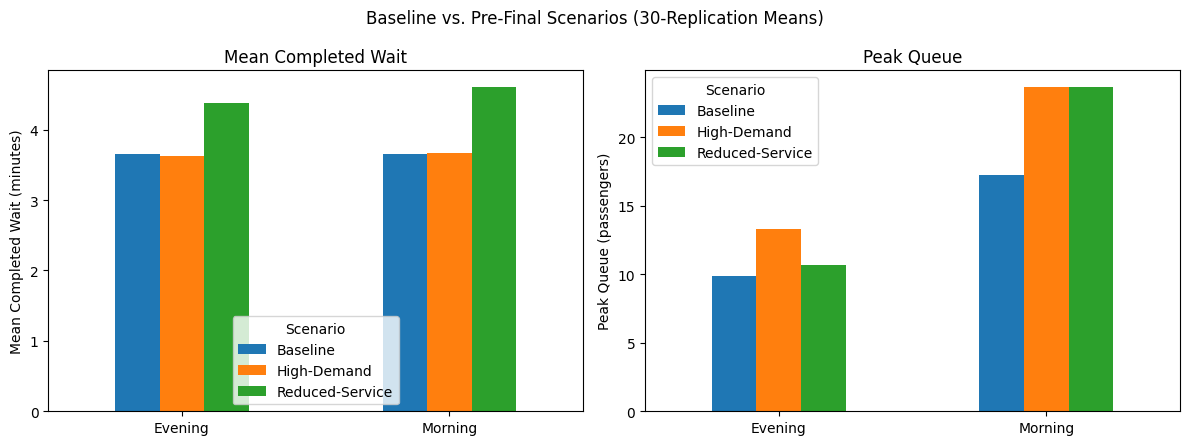

In [32]:
plt.style.use("default")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, metric, ylabel in zip(
    axes,
    ["Mean Completed Wait", "Peak Queue"],
    ["Mean Completed Wait (minutes)", "Peak Queue (passengers)"]
):
    pivot = scenario_summary.pivot(index="Period", columns="Scenario", values=metric)
    pivot = pivot[["Baseline", "High-Demand", "Reduced-Service"]]
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Baseline vs. Pre-Final Scenarios (30-Replication Means)")
fig.tight_layout()

fig.savefig(figures_dir / "07_scenario_comparison_mean_wait_and_peak_queue.png", dpi=150)
plt.show()


## 16. Save Handoff Outputs

In [33]:
# --- Scenario inputs / configuration ---
high_demand_demand.to_csv(
    processed_dir / "M66_HighDemand_Demand_Table.csv", index=False
)

scenario_config.to_csv(
    tables_dir / "scenario_configuration_parameters.csv", index=False
)

hourly_trip_counts_with_total.to_csv(
    tables_dir / "scenario_hourly_trip_counts.csv", index=False
)

# --- Reduced-Service reference schedule and removal documentation ---
reduced_service_plan.to_csv(
    processed_dir / "M66_ReducedService_Service_Plan.csv", index=False
)

removed_trips_df.to_csv(
    processed_dir / "M66_ReducedService_Removed_Trips.csv", index=False
)

reference_service_plan = reduced_study_stop_times[
    ["trip_id", "stop_sequence", "arrival_time", "arrival_minutes"]
].merge(
    reduced_trip_initial_occupancy[["trip_id", "Hour", "Period"]],
    on="trip_id",
    how="left"
).sort_values(["Hour", "trip_id", "stop_sequence"]).reset_index(drop=True)

reference_service_plan.to_csv(
    processed_dir / "M66_ReducedService_Reference_Schedule.csv", index=False
)

# --- Passenger streams ---
high_demand_master_streams.to_csv(
    processed_dir / "M66_HighDemand_Master_Passenger_Streams_30_Replications.csv",
    index=False
)

# Reduced-Service reuses the Baseline passenger streams — save them here too
# so this scenario's inputs are fully self-contained for Sofi's GA integration
# branch, without requiring a separate run of the baseline notebook.
baseline_master_streams.to_csv(
    processed_dir / "M66_Baseline_Master_Passenger_Streams_ReusedFor_ReducedService.csv",
    index=False
)

seed_table.to_csv(
    processed_dir / "M66_Scenario_Replication_Seeds.csv", index=False
)

# --- Simulation results (Baseline-compatible column format + Scenario column) ---
high_demand_results_df.to_csv(
    processed_dir / "M66_HighDemand_30_Replications.csv", index=False
)

reduced_service_results_df.to_csv(
    processed_dir / "M66_ReducedService_30_Replications.csv", index=False
)

all_scenario_results.to_csv(
    tables_dir / "scenario_vs_baseline_all_replications.csv", index=False
)

scenario_summary.to_csv(
    tables_dir / "scenario_vs_baseline_summary.csv", index=False
)

print("All High-Demand and Reduced-Service handoff outputs saved.")


All High-Demand and Reduced-Service handoff outputs saved.


## 17. What Changed From Baseline

**High-Demand scenario:**
- Passenger demand table (`high_demand_demand`): every stop-hour's representative mean Boardings is multiplied by `demand_growth_factor = 1.40`, then rounded with the same `max(0, floor(p + 0.5))` rule already used in Baseline. Structure (Stop Sequence, Stop Name, Hour) is unchanged.
- New passenger streams (`high_demand_master_streams`) are generated with the same 30 seeds as Baseline, using the generalized `generate_scenario_passengers()` function.
- GTFS reference schedule, initial occupancy, and alighting targets are **unchanged** from Baseline (per the scenario definition).
- Simulation engine: unchanged.

**Reduced-Service scenario:**
- Passenger demand and passenger streams: **unchanged** from Baseline (same `baseline_demand`, same 30 seeds, same `baseline_master_streams`).
- GTFS reference schedule: exactly one trip removed from every study hour using the deterministic median-position rule (Section 5). 10 trips removed total (77 remaining vs. 87 in Baseline).
- Initial occupancy (`reduced_initial_occupancy_lookup`) and alighting assignment (`reduced_alighting_lookup`) are recomputed for the remaining trips only — same underlying Upstream Net Flow and Alighting Target per hour as Baseline, redistributed across fewer buses.
- Simulation engine: unchanged.

**Both scenarios:**
- `bus_capacity`, `selected_stops`, `morning_hours`, `evening_hours`, `base_replications`, and `master_seed` are identical to Baseline, so scenario results stay directly comparable to the existing Baseline results.


## 18. Scope Boundary and Notes for the Group

- This notebook does **not** implement or change any GA/optimization logic. That component belongs to Sofi.
- The Combined scenario (High-Demand + Reduced-Service together) is **not** implemented here — it is listed as a separate planned item in the README and is out of scope for this handoff.
- **Assumption to confirm with the group:** upstream starting occupancy (Section 6) is derived from a separate upstream dataset and was intentionally left unchanged under High-Demand. If the GA optimizer (or the Combined scenario) should assume higher starting occupancy under High-Demand, that is a modeling decision to make together before the Combined scenario is built — flagging it here rather than deciding it unilaterally.
- **For Sofi's GA integration:** the Reduced-Service service budget is smaller than Baseline's (`Morning 38 / Evening 39` trips vs. Baseline's `Morning 43 / Evening 44` — see `scenario_configuration_parameters.csv`). If the GA's search space assumes the Baseline service budget, it will need the Reduced-Service budget as a separate constraint for any Reduced-Service or Combined optimization runs.
- Per the team's branching plan, this work stays on `feature/prefinal-scenarios` and is not merged into `main` yet. If GA integration needs these scenario outputs, please branch a separate integration branch from `feature/prefinal-scenarios` rather than committing directly here.


In [34]:
# TECHNICAL DOCUMENTATION USED (Pre-Final scenario additions)
#
# MTA Bus Stop Level Ridership:
# https://data.ny.gov/d/fvdm-uavx
#
# MTA Developer Resources / Static GTFS:
# https://www.mta.info/developers
#
# GTFS Schedule Reference:
# https://gtfs.org/documentation/schedule/reference/
#
# pandas documentation (groupby, sort_values, merge):
# https://pandas.pydata.org/docs/
#
# NumPy documentation (floor, random Generator, SeedSequence):
# https://numpy.org/doc/
#
# Python heapq documentation:
# https://docs.python.org/3/library/heapq.html
#
# Matplotlib documentation:
# https://matplotlib.org/stable/
#
# MAIN METHOD SOURCES USED IN THIS NOTEBOOK
#
# Kieu, L. M., & Cai, C. (2018). Stochastic collective model of public
# transport passenger arrival process. IET Intelligent Transport Systems.
# https://doi.org/10.1049/iet-its.2018.0085
# Used again here (same as Baseline) to justify keeping the within-hour
# arrival-time sampling method identical between scenarios, and only
# varying the fixed hourly passenger count.
#
# Currie, G., & Wallis, I. (2008). Effective ways to grow urban bus markets
# - a synthesis of evidence. Journal of Transport Geography, 16(6), 419-429.
# https://doi.org/10.1016/j.jtrangeo.2008.04.007
# Discusses demand-growth scenario analysis as a standard sensitivity-testing
# approach for bus service planning; used to support scaling representative
# demand by a fixed percentage as a deterministic high-demand stress test.
#
# El-Geneidy, A., Horning, J., & Krizek, K. J. (2011). Analyzing transit
# service reliability using detailed data from automatic vehicular locator
# systems. Journal of Transport Geography, 19(4), 853-863.
# https://doi.org/10.1016/j.jtrangeo.2010.10.005
# Discusses the passenger-waiting-time impact of missed/reduced scheduled
# trips; used to support the Reduced-Service scenario's trip-removal design
# and its expected effect on completed waiting time.
#
# CODE ADAPTATION NOTE
# No third-party GitHub repository code was adapted for this notebook.
# All scenario logic in Sections 3, 5, and 7 was written for this handoff,
# generalizing functions already present in m66_baseline_simulation.ipynb
# (see Sections 8 and 9 for exactly which functions were reused unmodified
# vs. generalized).
